# Tiny Dreamer Highway — Colab H100 Run

**Name:** Esteban  
**Course:** CSC 580 AI 2  
**Assignment:** Final Project — Dream the Road  
**AI tools consulted:** GitHub Copilot

Use this notebook only after the baseline real run is stable and you want to make better use of an H100 runtime.

## H100 intent

This notebook uses the larger H100-oriented config. Compare its runtime and final metrics against the baseline notebook, not against the sanity notebook.

When reviewing results, check both policy metrics and world-model metrics: mean reward, crash rate, observation likelihood, and overshooting consistency.

In [1]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git pull --ff-only origin main
fi
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

Already up to date.


From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main       -> FETCH_HEAD


In [3]:
import json
import sys
import torch
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

CONFIG_PATH = PROJECT_ROOT / 'examples' / 'h100_experiment.yaml'
config = load_experiment_config(CONFIG_PATH)

def print_sequence_sampling_guidance(run_label, warm_start_steps):
    effective_warm_start = config.training.warm_start_steps if warm_start_steps is None else warm_start_steps
    nominal_floor = config.training.batch_size * config.replay.sequence_length
    print(f'{run_label} sequence length:', config.replay.sequence_length)
    print(f'{run_label} max episode steps:', config.env.max_episode_steps)
    print(f'{run_label} offroad terminal:', config.env.reward.offroad_terminal)
    print(f'{run_label} effective warm-start steps:', effective_warm_start)
    print(f'{run_label} nominal warm-start floor (batch x sequence):', nominal_floor)
    print('Trainer safeguard: extra random warm-start data will be collected automatically if valid sequences are still unavailable.')
    if config.replay.sequence_length > config.env.max_episode_steps:
        print('Warning: sequence_length exceeds max_episode_steps, so replay sequence sampling is impossible.')
    elif config.env.reward.offroad_terminal and config.replay.sequence_length >= config.env.max_episode_steps - 8:
        print('Caution: sequence_length is close to the episode horizon while offroad_terminal=True; short crash-heavy warm starts may require extra random collection.')
    elif effective_warm_start < nominal_floor:
        print('Caution: warm-start is below the nominal batch_size x sequence_length floor.')

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'
print('Loaded config from:', CONFIG_PATH)
print('GPU:', gpu_name)
if 'H100' not in gpu_name:
    print('Warning: this notebook is intended for H100-class runtimes.')
print('Batch size:', config.training.batch_size)
print('World-model updates/cycle:', config.training.world_model_updates_per_cycle)
print('Behavior updates/cycle:', config.training.behavior_updates_per_cycle)

Loaded config from: /content/CSC_580_Final_Project/examples/h100_experiment.yaml
GPU: NVIDIA H100 80GB HBM3
Batch size: 128
World-model updates/cycle: 8
Behavior updates/cycle: 8


In [4]:
RUN_NAME = 'h100_real_run_001'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

CYCLES = None
WARM_START_STEPS = None
POLICY_STEPS = None
CHECKPOINT_INTERVAL = None
RESUME_FROM = None

print('Run name:', RUN_NAME)
print('Effective cycles:', config.training.cycles if CYCLES is None else CYCLES)
print('Effective policy steps:', config.training.policy_steps if POLICY_STEPS is None else POLICY_STEPS)
print_sequence_sampling_guidance('H100 run', WARM_START_STEPS)

Run name: h100_real_run_001
Effective cycles: 500


In [5]:
print('Launching H100 run. Per-cycle progress lines will appear below.')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('Completed cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching H100 run. Per-cycle progress lines will appear below.
[train] starting run | cycles=500 | start_step=1 | warm_start_steps=2000 | policy_steps=64 | device=cuda
[train] step=1/500 | warm=2000 | policy=64 | replay=2064 | world_total=3.2360 | actor=-0.8101 | critic=0.6885 | cycle_s=470.0 | elapsed_s=470.0 | checkpoint=-
[train] step=2/500 | warm=0 | policy=64 | replay=2128 | world_total=3.1504 | actor=-0.9970 | critic=0.9332 | cycle_s=15.0 | elapsed_s=485.0 | checkpoint=-
[train] step=3/500 | warm=0 | policy=64 | replay=2192 | world_total=3.0980 | actor=-0.9661 | critic=0.7817 | cycle_s=14.8 | elapsed_s=499.7 | checkpoint=-
[train] step=4/500 | warm=0 | policy=64 | replay=2256 | world_total=3.0847 | actor=-1.1652 | critic=1.0966 | cycle_s=14.8 | elapsed_s=514.5 | checkpoint=-
[train] step=5/500 | warm=0 | policy=64 | replay=2320 | world_total=3.0741 | actor=-1.2609 | critic=1.2116 | cycle_s=14.9 | elapsed_s=529.3 | checkpoint=-
[train] step=6/500 | warm=0 | policy=64 | replay=238

In [6]:
summary_path = training_summary.log_dir / 'latest_summary.json'
summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))
summary_payload

{'checkpoint_file': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/h100_real_run_001/checkpoints/checkpoint_00500.pt',
 'latest_metrics': {'behavior/actor_loss': -26.78359317779541,
  'behavior/critic_loss': 1.37691430747509,
  'behavior/imagined_reward_mean': 0.25541456043720245,
  'behavior/imagined_value_mean': 26.658080577850342,
  'policy_added': 64,
  'replay_size': 34000,
  'step': 500,
  'warm_start_added': 0,
  'world_model/kl_loss': 3.0,
  'world_model/kl_loss_raw': 2.1114122569561005,
  'world_model/reconstruction_loss': 0.016658008098602295,
  'world_model/reward_loss': 0.12661823257803917,
  'world_model/total_loss': 3.1432762145996094},
 'latest_step': 500}

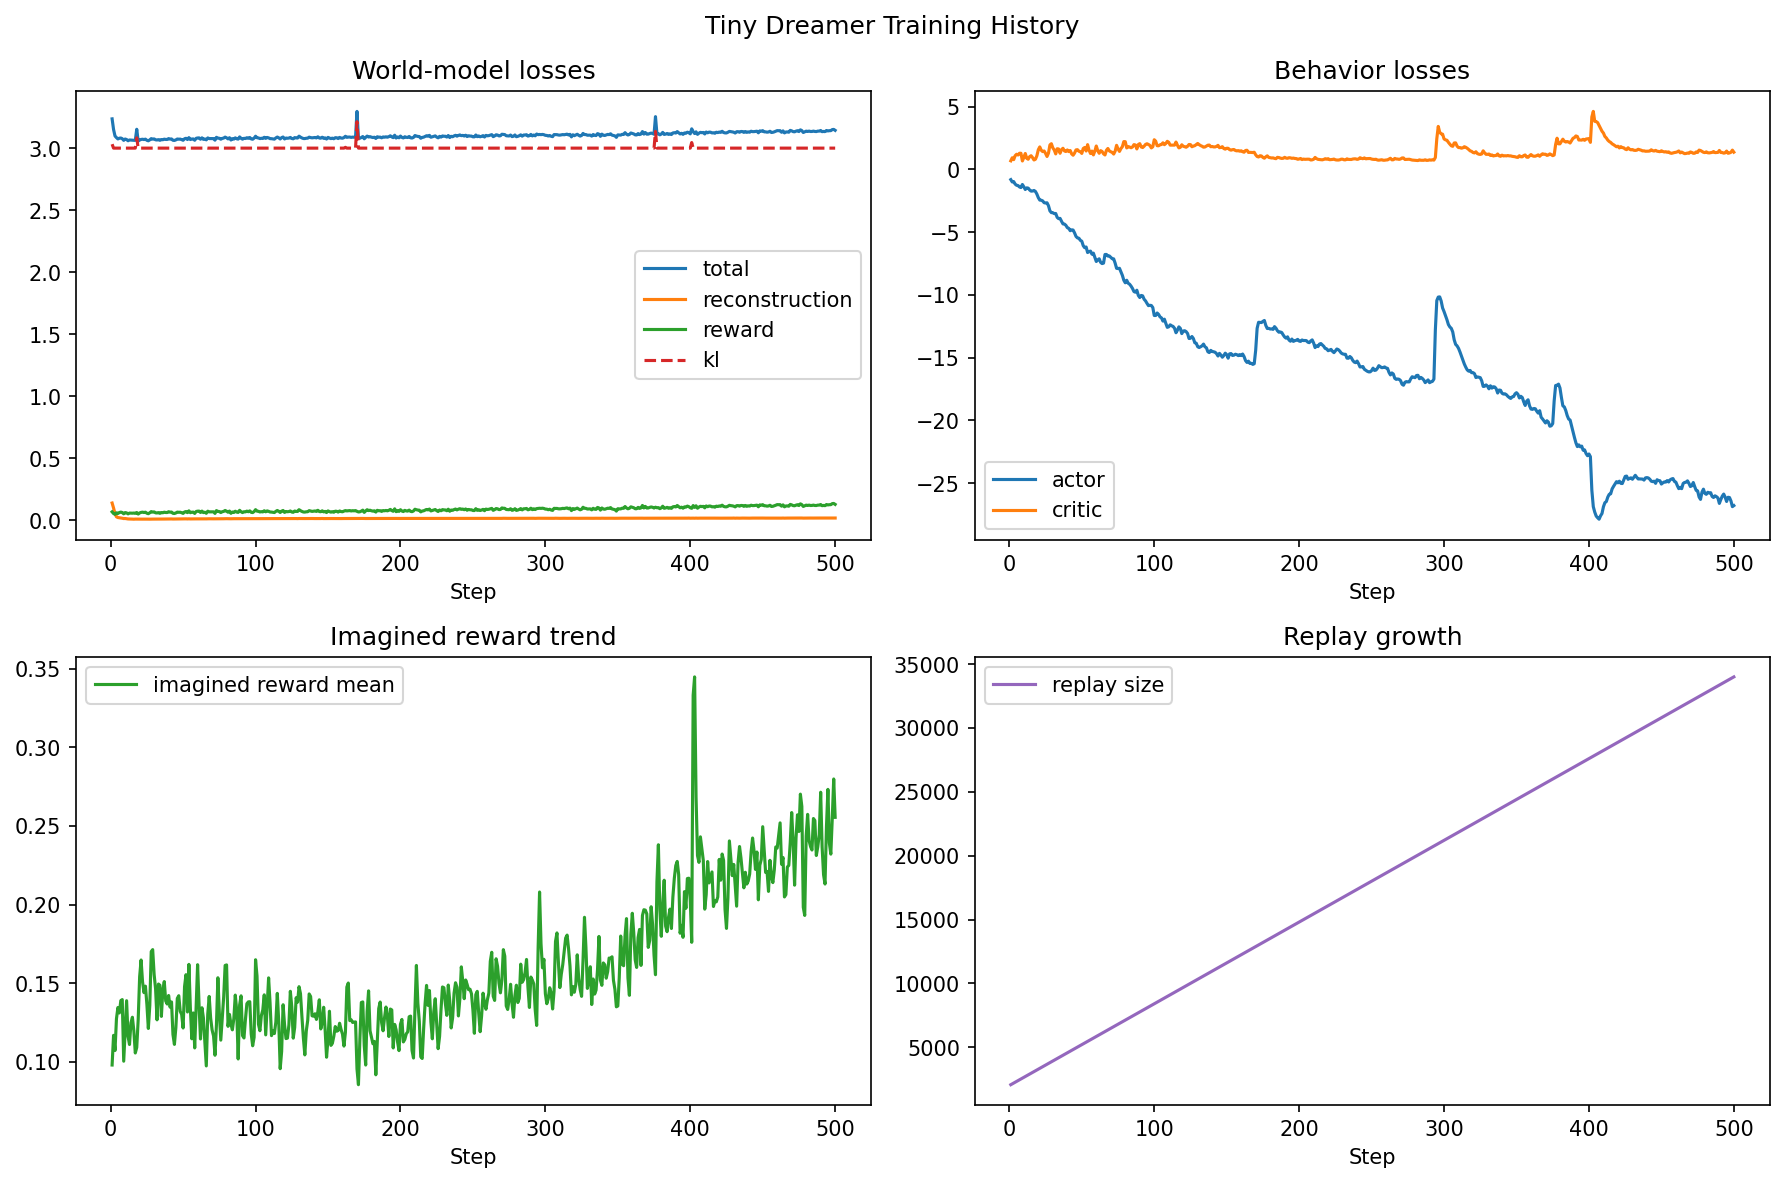

{'best_imagined_reward_mean': 0.34468552470207214,
 'best_imagined_reward_step': 403,
 'best_world_model_step': 19,
 'best_world_model_total_loss': 3.056164175271988,
 'largest_replay_size': 34000,
 'largest_replay_step': 500,
 'last_metrics': {'behavior/actor_loss': -26.78359317779541,
  'behavior/critic_loss': 1.37691430747509,
  'behavior/imagined_reward_mean': 0.25541456043720245,
  'behavior/imagined_value_mean': 26.658080577850342,
  'policy_added': 64,
  'replay_size': 34000,
  'step': 500,
  'warm_start_added': 0,
  'world_model/kl_loss': 3.0,
  'world_model/kl_loss_raw': 2.1114122569561005,
  'world_model/reconstruction_loss': 0.016658008098602295,
  'world_model/reward_loss': 0.12661823257803917,
  'world_model/total_loss': 3.1432762145996094},
 'last_step': 500,
 'num_records': 500}

In [7]:
from IPython.display import Image, display
import csv
import importlib
import json
import tiny_dreamer_highway.evaluation.training_analysis as training_analysis

training_analysis = importlib.reload(training_analysis)
export_training_history_artifacts = training_analysis.export_training_history_artifacts

analysis_outputs = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

display(Image(filename=str(analysis_outputs['curves'])))
analysis_summary = json.loads(analysis_outputs['summary'].read_text(encoding='utf-8'))
with (training_summary.log_dir / 'cycle_metrics.csv').open('r', encoding='utf-8', newline='') as handle:
    metric_rows = list(csv.DictReader(handle))
latest_metrics_row = metric_rows[-1]
{
    'analysis_summary': analysis_summary,
    'phase4_metrics': {
        'world_model/reconstruction_loss': latest_metrics_row.get('world_model/reconstruction_loss'),
        'world_model/reconstruction_mse': latest_metrics_row.get('world_model/reconstruction_mse'),
        'world_model/observation_log_prob': latest_metrics_row.get('world_model/observation_log_prob'),
        'world_model/overshooting_kl_loss': latest_metrics_row.get('world_model/overshooting_kl_loss'),
        'world_model/overshooting_feature_mse': latest_metrics_row.get('world_model/overshooting_feature_mse'),
        'world_model/overshooting_pairs': latest_metrics_row.get('world_model/overshooting_pairs'),
        'evaluation/mean_reward': latest_metrics_row.get('evaluation/mean_reward'),
        'evaluation/crash_rate': latest_metrics_row.get('evaluation/crash_rate'),
    },
}

## Agent Driving Demo

Record a short GIF showing the trained policy driving in the real highway-env. The checkpoint from the run above is used to load the actor and world model, then the agent is rolled out for a few episodes.

Using demo recorder from: tiny_dreamer_highway.evaluation.policy_rollout
[demo] episode 1/2 | steps=40 | reward=30.19 | OK | saved h100_real_run_001_ep01.gif
[demo] episode 2/2 | steps=40 | reward=18.38 | OK | saved h100_real_run_001_ep02.gif
[demo] done | avg_reward=24.28 | summary=h100_real_run_001_summary.json

h100_real_run_001_ep01.gif


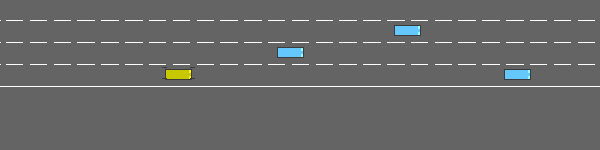


h100_real_run_001_ep02.gif


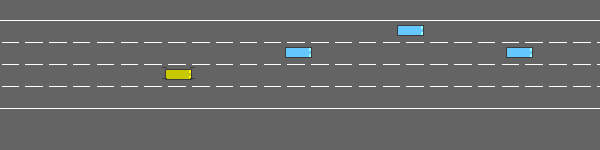

In [9]:
from IPython.display import Image, display
import importlib
import tiny_dreamer_highway.evaluation as evaluation_pkg

try:
    evaluation_pkg = importlib.reload(evaluation_pkg)
    record_demo_videos = evaluation_pkg.record_demo_videos
except (AttributeError, ImportError):
    from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos

print('Using demo recorder from:', record_demo_videos.__module__)

demo_outputs = record_demo_videos(
    config,
    checkpoint_path=training_summary.latest_checkpoint,
    output_dir=RUN_ARTIFACT_ROOT / 'demo_videos',
    num_episodes=2,
    max_steps=1000,
    fps=15,
    seed=config.seed,
    prefix=RUN_NAME,
    device=config.device,
)

for gif_path in demo_outputs.video_paths:
    print(f'\n{gif_path.name}')
    display(Image(filename=str(gif_path)))